In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score


In [2]:
url = "https://raw.githubusercontent.com/rikhuijzer/heart-disease-dataset/main/heart-disease-dataset.csv"
df = pd.read_csv(url)
df.head()

,age,sex,chest_pain_type,resting_bp_s,cholesterol,fasting_blood_sugar,resting_ecg,max_heart_rate,exercise_angina,oldpeak,st_slope,target
0,40.0,1.0,2.0,140.0,289.0,0.0,0.0,172.0,0.0,0.0,1.0,0.0
1,49.0,0.0,3.0,160.0,180.0,0.0,0.0,156.0,0.0,1.0,2.0,1.0
2,37.0,1.0,2.0,130.0,283.0,0.0,1.0,98.0,0.0,0.0,1.0,0.0
3,48.0,0.0,4.0,138.0,214.0,0.0,0.0,108.0,1.0,1.5,2.0,1.0
4,54.0,1.0,3.0,150.0,195.0,0.0,0.0,122.0,0.0,0.0,1.0,0.0


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1190 entries, 0 to 1189
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  1190 non-null   float64
 1   sex                  1190 non-null   float64
 2   chest_pain_type      1190 non-null   float64
 3   resting_bp_s         1190 non-null   float64
 4   cholesterol          1190 non-null   float64
 5   fasting_blood_sugar  1190 non-null   float64
 6   resting_ecg          1190 non-null   float64
 7   max_heart_rate       1190 non-null   float64
 8   exercise_angina      1190 non-null   float64
 9   oldpeak              1190 non-null   float64
 10  st_slope             1190 non-null   float64
 11  target               1190 non-null   float64
dtypes: float64(12)
memory usage: 111.7 KB


In [4]:
df.isnull().sum()


age                    0
sex                    0
chest_pain_type        0
resting_bp_s           0
cholesterol            0
fasting_blood_sugar    0
resting_ecg            0
max_heart_rate         0
exercise_angina        0
oldpeak                0
st_slope               0
target                 0
dtype: int64

In [5]:
# UPGRADE: Check target balance and duplicate rows for a stronger preprocessing story
print("Target class distribution:\n", df['target'].value_counts())
print("\nDuplicate rows:", df.duplicated().sum())


Target class distribution:
 1.0    629
0.0    561
Name: target, dtype: int64

Duplicate rows: 272


In [6]:
X = df.drop('target', axis=1)
y = df['target']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # UPGRADE: preserve class balance
)


In [8]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
# ================================
# Logistic Regression - Baseline
# ================================
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train, y_train)


LogisticRegression(max_iter=1000)

In [10]:
y_pred = lr_model.predict(X_test)


In [11]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy


0.8403361344537815

In [12]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
cm


array([[ 92,  20],
       [ 18, 108]], dtype=int64)

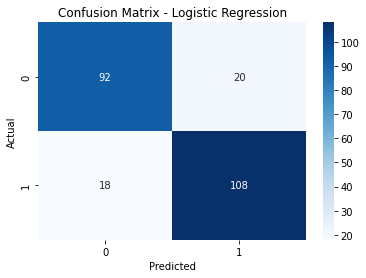

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [14]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

         0.0       0.84      0.82      0.83       112
         1.0       0.84      0.86      0.85       126

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238



In [15]:
# ================================
# Random Forest - Model Refinement
# ================================
from sklearn.ensemble import RandomForestClassifier

In [16]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

In [17]:
y_pred_rf = rf_model.predict(X_test)


In [18]:
from sklearn.metrics import accuracy_score

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_accuracy


0.9285714285714286

In [19]:
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf


array([[103,   9],
       [  8, 118]], dtype=int64)

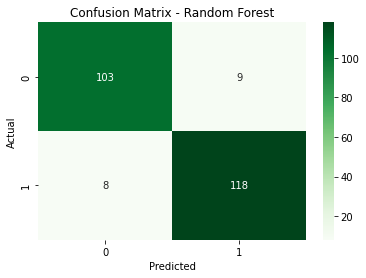

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [21]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))


              precision    recall  f1-score   support

         0.0       0.93      0.92      0.92       112
         1.0       0.93      0.94      0.93       126

    accuracy                           0.93       238
   macro avg       0.93      0.93      0.93       238
weighted avg       0.93      0.93      0.93       238



In [22]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)


Logistic Regression Accuracy: 0.8403361344537815
Random Forest Accuracy: 0.9285714285714286


In [23]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [24]:
svm_model = SVC(kernel='rbf')  # you can also try 'rbf'
svm_model.fit(X_train, y_train)

SVC()

In [25]:
y_pred_svm = svm_model.predict(X_test)

In [26]:
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))
print("Classification Report:\n", classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.8781512605042017
Confusion Matrix:
 [[ 94  18]
 [ 11 115]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.90      0.84      0.87       112
         1.0       0.86      0.91      0.89       126

    accuracy                           0.88       238
   macro avg       0.88      0.88      0.88       238
weighted avg       0.88      0.88      0.88       238



In [27]:
print("Logistic Regression Accuracy:", accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

Logistic Regression Accuracy: 0.8403361344537815
Random Forest Accuracy: 0.9285714285714286
SVM Accuracy: 0.8781512605042017


In [28]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("Gradient Boosting Accuracy:", accuracy_score(y_test, y_pred_gb))

Gradient Boosting Accuracy: 0.9033613445378151


In [29]:
# UPGRADE: Evaluate models with stratified cross-validation instead of relying on one split only
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf'),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42)
}

for name, model in baseline_models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring='accuracy')
    print(f"{name}: CV Accuracy = {scores.mean():.4f} +/- {scores.std():.4f}")


Logistic Regression: CV Accuracy = 0.8267 +/- 0.0328
Random Forest: CV Accuracy = 0.9181 +/- 0.0243
SVM: CV Accuracy = 0.8656 +/- 0.0289
Gradient Boosting: CV Accuracy = 0.8834 +/- 0.0282


In [30]:
# UPGRADE: Tune Random Forest so the final model is justified, not just a default setting
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)
best_rf_model = rf_grid.best_estimator_
print('Best Random Forest Parameters:', rf_grid.best_params_)
print('Best CV Accuracy:', rf_grid.best_score_)


Best Random Forest Parameters: {'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9191127032240287


In [31]:
# UPGRADE: Evaluate tuned Random Forest with richer metrics for project defense
y_pred_best_rf = best_rf_model.predict(X_test)
y_prob_best_rf = best_rf_model.predict_proba(X_test)[:, 1]

print('Tuned Random Forest Accuracy:', accuracy_score(y_test, y_pred_best_rf))
print('Tuned Random Forest ROC-AUC:', roc_auc_score(y_test, y_prob_best_rf))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_best_rf))
print('Classification Report:\n', classification_report(y_test, y_pred_best_rf))


Tuned Random Forest Accuracy: 0.9243697478991597
Tuned Random Forest ROC-AUC: 0.9706632653061225
Confusion Matrix:
 [[103   9]
 [  9 117]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.92      0.92      0.92       112
         1.0       0.93      0.93      0.93       126

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weighted avg       0.92      0.92      0.92       238



In [32]:
# UPGRADE: Show feature importance for interpretability in viva/presentation
feature_importance = pd.Series(best_rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)
print(feature_importance)


st_slope               0.181947
chest_pain_type        0.127903
oldpeak                0.119206
cholesterol            0.116069
max_heart_rate         0.113985
age                    0.091465
resting_bp_s           0.085871
exercise_angina        0.076789
sex                    0.045412
resting_ecg            0.023410
fasting_blood_sugar    0.017943
dtype: float64


In [33]:
import joblib
# UPGRADE: Save tuned Random Forest as the final production model
joblib.dump(best_rf_model, "best_model.pkl")

['best_model.pkl']

In [34]:
import joblib
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']